# 04 — Ablation Study

Systematically disable one rule module at a time to measure its contribution to overall accuracy.

| Rule Module | Description |
|---|---|
| `punct_num` | Punctuation & numeral regex rules |
| `closed_class` | Hardcoded closed-class word lists |
| `lexicon` | Most-frequent-tag lookup |
| `capitalization` | Casing-based PROPN detection |
| `morphology` | Suffix-based tag guessing |
| `context` | Neighbour-tag context rules |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.parser import parse_conllu, get_forms_and_tags
from src.lexicon import Lexicon
from src.tagger import RuleBasedTagger
from src.evaluate import Evaluator

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

In [2]:
# Load data
train_sents = parse_conllu('../data/en_ewt-ud-train.conllu')
dev_sents = parse_conllu('../data/en_ewt-ud-dev.conllu')

lexicon = Lexicon().build(train_sents)
tagger = RuleBasedTagger(lexicon)
dev_corpus = get_forms_and_tags(dev_sents)

In [3]:
# Run ablation
rules = ['none', 'punct_num', 'closed_class', 'lexicon',
         'capitalization', 'morphology', 'context']

ablation_results = {}
for rule in rules:
    if rule == 'none':
        tagged = tagger.tag_corpus(dev_corpus)
    else:
        tagged = []
        for words, gold in dev_corpus:
            pred = tagger.tag_sentence_ablation(words, disable=rule)
            tagged.append((words, gold, pred))
    
    acc = Evaluator.accuracy(tagged)
    ablation_results[rule] = acc
    print(f'  {rule:<20} accuracy = {acc:.4f}')

print(f'\nFull system accuracy: {ablation_results["none"]:.4f}')

  none                 accuracy = 0.8722
  punct_num            accuracy = 0.8728
  closed_class         accuracy = 0.8804
  lexicon              accuracy = 0.5656
  capitalization       accuracy = 0.8573
  morphology           accuracy = 0.8687
  context              accuracy = 0.8720

Full system accuracy: 0.8722


In [4]:
# Ablation table
full_acc = ablation_results['none']
rows = []
for rule, acc in ablation_results.items():
    rows.append({
        'Rule Disabled': rule,
        'Accuracy': acc,
        'Accuracy Drop': full_acc - acc,
        'Relative Drop (%)': (full_acc - acc) / full_acc * 100 if full_acc > 0 else 0,
    })

df_ablation = pd.DataFrame(rows).sort_values('Accuracy Drop', ascending=False)
print(df_ablation.to_string(index=False))

# Save
os.makedirs('../outputs', exist_ok=True)
df_ablation.to_csv('../outputs/ablation_table.csv', index=False)
print(f'\nSaved to outputs/ablation_table.csv')

 Rule Disabled  Accuracy  Accuracy Drop  Relative Drop (%)
       lexicon  0.565634       0.306557          35.147951
capitalization  0.857319       0.014873           1.705193
    morphology  0.868732       0.003460           0.396663
       context  0.871953       0.000239           0.027356
          none  0.872192       0.000000           0.000000
     punct_num  0.872788      -0.000596          -0.068390
  closed_class  0.880383      -0.008192          -0.939224

Saved to outputs/ablation_table.csv


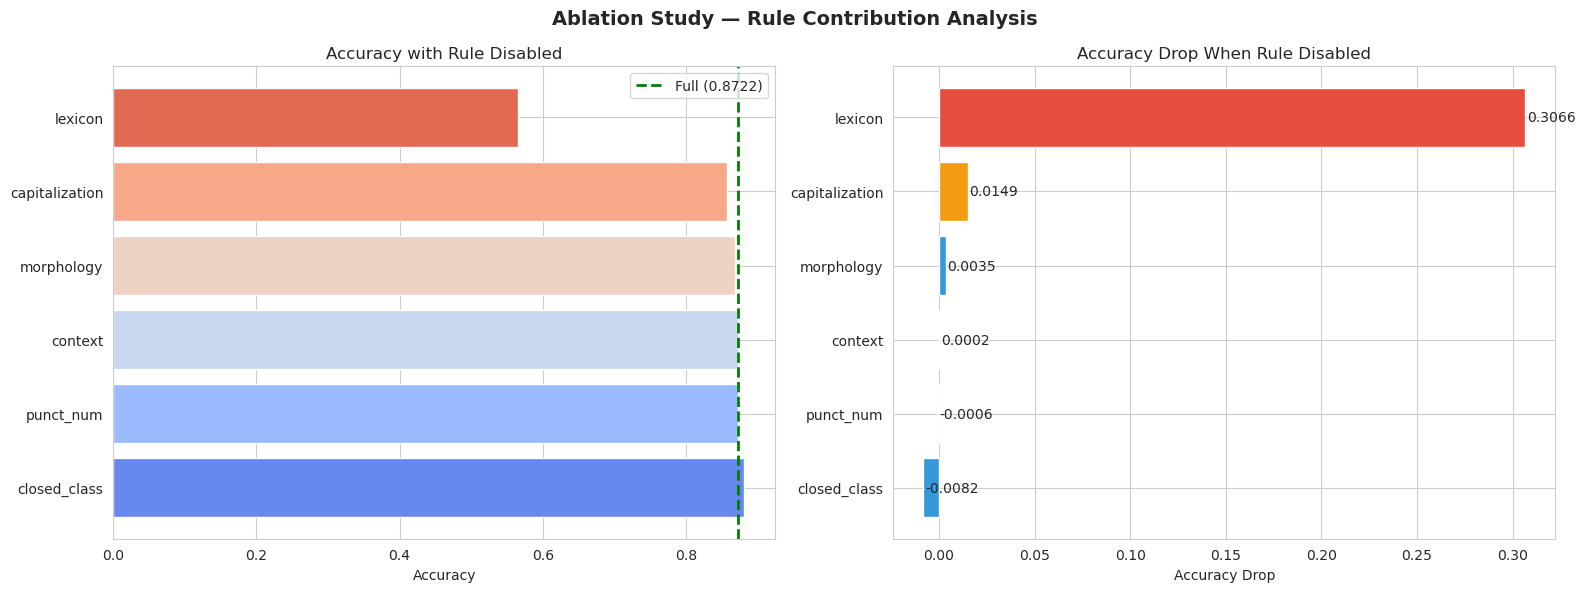

In [5]:
# Ablation bar chart
df_plot = df_ablation[df_ablation['Rule Disabled'] != 'none'].sort_values('Accuracy Drop')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy when disabled
colors = sns.color_palette('coolwarm', len(df_plot))
axes[0].barh(df_plot['Rule Disabled'], df_plot['Accuracy'], color=colors)
axes[0].axvline(full_acc, color='green', linestyle='--', linewidth=2, label=f'Full ({full_acc:.4f})')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy with Rule Disabled')
axes[0].legend()

# Accuracy drop
colors_drop = ['#e74c3c' if d > 0.05 else '#f39c12' if d > 0.01 else '#3498db'
               for d in df_plot['Accuracy Drop']]
axes[1].barh(df_plot['Rule Disabled'], df_plot['Accuracy Drop'], color=colors_drop)
axes[1].set_xlabel('Accuracy Drop')
axes[1].set_title('Accuracy Drop When Rule Disabled')
for i, v in enumerate(df_plot['Accuracy Drop']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Ablation Study — Rule Contribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/ablation_chart.png', dpi=150)
plt.show()

## Key Findings

After running all cells above, examine:
1. **Which rule contributes most?** (largest accuracy drop when disabled)
2. **Which rule contributes least?** (smallest drop — candidate for removal)
3. **Are any rules harmful?** (accuracy *increases* when disabled)